# Notebook 06 — Support Vector Machine (SVM)
**Regression** → Predict WQI
**Classification** → Predict Water Quality Category

### Why SVM?
- Finds the **optimal boundary** (hyperplane) that best separates classes
- Maximizes the **margin** — distance between the boundary and nearest points
- Those nearest points are called **Support Vectors** — only they define the boundary
- Works well in **high dimensional spaces** (many features)
- The **kernel trick** maps data into higher dimensions to find non-linear boundaries
without actually computing in that higher dimension

### Kernel Types:
| Kernel | When to use |
|---|---|
| linear | Data is linearly separable |
| rbf (Gaussian) | Most common — handles non-linear boundaries |
| poly | Polynomial relationships between features |

In [2]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.svm import SVR, SVC
from sklearn.metrics import (
  r2_score, mean_squared_error, mean_absolute_error,
  accuracy_score, f1_score, classification_report, confusion_matrix
)


In [3]:
with open('processed_data.pkl', 'rb') as f:
  data = pickle.load(f)

X_train       = data['X_train']
X_test        = data['X_test']
y_reg_train   = data['y_reg_train']
y_reg_test    = data['y_reg_test']
y_clf_train   = data['y_clf_train']
y_clf_test    = data['y_clf_test']
le            = data['label_encoder']
feature_names = data['feature_names']

print("Train size:", X_train.shape)
print("Test  size:", X_test.shape)
print("Classes   :", list(le.classes_))

Train size: (15223, 30)
Test  size: (3806, 30)
Classes   : ['Excellent', 'Good', 'Poor', 'Unsuitable for Drinking', 'Very Poor yet Drinkable']


## Important Note — SVM and Large Datasets

SVM training time scales as **O(n²) to O(n³)** with number of samples.
Our dataset has ~15,000 training samples — full SVM will be very slow.

Solution: Use a **random subset** for SVM training to keep it manageable.
This is common practice when using SVM on large datasets.

Key Parameters:
- `C` → regularization — high C = fits training data closely (risk overfit)
            low C = smoother boundary (risk underfit)
- `kernel` → type of boundary (linear, rbf, poly)
- `gamma` → how far influence of each sample reaches (rbf kernel)
          high gamma = close reach, low gamma = far reach

In [5]:
#(Sample Data for Speed)

from sklearn.utils import resample

# Use 3000 samples for training — SVM is slow on large datasets
SAMPLE_SIZE = 3000

X_train_svm, y_reg_train_svm, y_clf_train_svm = resample(
  X_train, y_reg_train, y_clf_train,
  n_samples=SAMPLE_SIZE,
  random_state=42
)

print(f"SVM Training size : {X_train_svm.shape}")
print(f"Full test set used: {X_test.shape}")

SVM Training size : (3000, 30)
Full test set used: (3806, 30)


## Part 1 — SVR (Support Vector Regression)
SVR finds a tube (called epsilon-tube) around the regression line.
Points inside the tube are ignored — only points outside define the boundary.
This makes SVR robust to small errors and outliers.

In [6]:
#(Train SVR)

from sklearn.svm import SVR

svr_model = SVR(kernel='rbf', C=100, gamma='scale', epsilon=0.1)
svr_model.fit(X_train_svm, y_reg_train_svm)

y_pred_train = svr_model.predict(X_train_svm)
y_pred_test  = svr_model.predict(X_test)

r2_train = r2_score(y_reg_train_svm, y_pred_train)
r2_test  = r2_score(y_reg_test,      y_pred_test)
rmse     = np.sqrt(mean_squared_error(y_reg_test, y_pred_test))
mae      = mean_absolute_error(y_reg_test, y_pred_test)

print("=== SVR (RBF Kernel) ===")
print(f"R² Train : {r2_train:.4f}")
print(f"R² Test  : {r2_test:.4f}")
print(f"RMSE     : {rmse:.2f}")
print(f"MAE      : {mae:.2f}")
print(f"Support Vectors used: {svr_model.n_support_}")

=== SVR (RBF Kernel) ===
R² Train : 0.5841
R² Test  : 0.6007
RMSE     : 205.06
MAE      : 23.14
Support Vectors used: [2904]


In [8]:
#(Compare Kernels — Regression)

kernels = ['linear', 'rbf', 'poly']
kernel_results = []

for kernel in kernels:
  m = SVR(kernel=kernel, C=100, gamma='scale')
  m.fit(X_train_svm, y_reg_train_svm)
  r2 = r2_score(y_reg_test, m.predict(X_test))
  rmse_k = np.sqrt(mean_squared_error(y_reg_test, m.predict(X_test)))
  kernel_results.append({
      'Kernel': kernel,
      'R² Test': round(r2, 4),
      'RMSE': round(rmse_k, 2),
      'Support Vectors': m.n_support_
  })

pd.DataFrame(kernel_results)

,Kernel,R² Test,RMSE,Support Vectors
0,linear,1.0000,0.04,[23]
1,rbf,0.6007,205.06,[2904]
2,poly,0.2344,283.93,[2978]


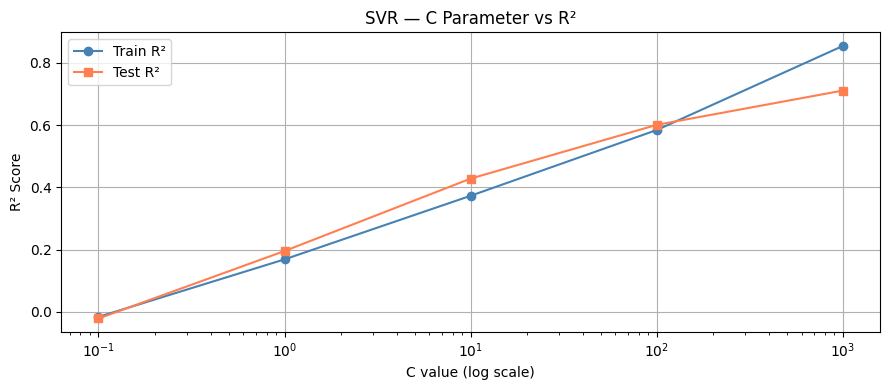

In [9]:
#(C Parameter Effect)
C_values = [0.1, 1, 10, 100, 1000]
train_scores, test_scores = [], []

for c in C_values:
  m = SVR(kernel='rbf', C=c, gamma='scale')
  m.fit(X_train_svm, y_reg_train_svm)
  train_scores.append(r2_score(y_reg_train_svm, m.predict(X_train_svm)))
  test_scores.append(r2_score(y_reg_test,       m.predict(X_test)))

plt.figure(figsize=(9, 4))
plt.plot(C_values, train_scores, marker='o', label='Train R²', color='steelblue')
plt.plot(C_values, test_scores,  marker='s', label='Test R²',  color='coral')
plt.xscale('log')
plt.xlabel('C value (log scale)')
plt.ylabel('R² Score')
plt.title('SVR — C Parameter vs R²')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



## Part 2 — SVC (Support Vector Classification)

SVM handles multi-class using **One vs One (OvO)** strategy by default:
- Trains one classifier for every pair of classes
- With 5 classes → 5×4/2 = **10 binary classifiers** trained
- Final prediction = class that wins the most pairwise votes



In [10]:
#(Train SVC)

from sklearn.svm import SVC

svc_model = SVC(
  kernel='rbf',
  C=100,
  gamma='scale',
  decision_function_shape='ovo',
  random_state=42
)
svc_model.fit(X_train_svm, y_clf_train_svm)

y_clf_pred_train = svc_model.predict(X_train_svm)
y_clf_pred_test  = svc_model.predict(X_test)

acc_train = accuracy_score(y_clf_train_svm, y_clf_pred_train)
acc_test  = accuracy_score(y_clf_test,      y_clf_pred_test)
f1_test   = f1_score(y_clf_test, y_clf_pred_test, average='weighted')

print("=== SVC (RBF Kernel) ===")
print(f"Accuracy Train : {acc_train:.4f}")
print(f"Accuracy Test  : {acc_test:.4f}")
print(f"F1 Score Test  : {f1_test:.4f}")
print(f"Support Vectors per class: {svc_model.n_support_}")

=== SVC (RBF Kernel) ===
Accuracy Train : 0.9897
Accuracy Test  : 0.9377
F1 Score Test  : 0.9375
Support Vectors per class: [ 61 136 221 143 207]


In [11]:
#(Compare Kernels — Classification)

kernel_clf_results = []

for kernel in kernels:
  m = SVC(kernel=kernel, C=100, gamma='scale', random_state=42)
  m.fit(X_train_svm, y_clf_train_svm)
  acc = accuracy_score(y_clf_test, m.predict(X_test))
  f1  = f1_score(y_clf_test, m.predict(X_test), average='weighted')
  kernel_clf_results.append({
      'Kernel': kernel,
      'Accuracy Test': round(acc, 4),
      'F1 Test': round(f1, 4),
      'Total Support Vectors': sum(m.n_support_)
  })

pd.DataFrame(kernel_clf_results)

,Kernel,Accuracy Test,F1 Test,Total Support Vectors
0,linear,0.9769,0.9769,255
1,rbf,0.9377,0.9375,768
2,poly,0.8752,0.8748,1489


In [12]:
#(Classification Report)

print("=== SVC Classification Report ===")
print(classification_report(
  y_clf_test,
  y_clf_pred_test,
  target_names=le.classes_
))


=== SVC Classification Report ===
                         precision    recall  f1-score   support

              Excellent       0.84      0.92      0.88       136
                   Good       0.88      0.81      0.84       317
                   Poor       0.92      0.94      0.93      1066
Unsuitable for Drinking       0.98      0.98      0.98      1370
Very Poor yet Drinkable       0.93      0.92      0.92       917

               accuracy                           0.94      3806
              macro avg       0.91      0.91      0.91      3806
           weighted avg       0.94      0.94      0.94      3806



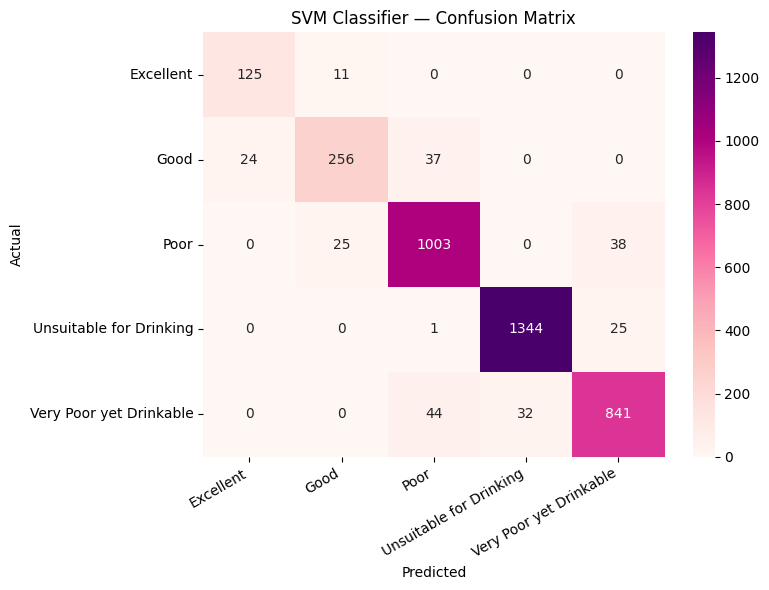

In [13]:
#(Confusion Matrix)

cm = confusion_matrix(y_clf_test, y_clf_pred_test)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdPu',
          xticklabels=le.classes_,
          yticklabels=le.classes_)
plt.title('SVM Classifier — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


In [14]:
#(Full Comparison Table)

with open('results_01_linear_logistic.pkl', 'rb') as f:
  res_01 = pickle.load(f)
with open('results_02_decision_tree.pkl', 'rb') as f:
  res_02 = pickle.load(f)
with open('results_03_random_forest.pkl', 'rb') as f:
  res_03 = pickle.load(f)
with open('results_04_xgboost.pkl', 'rb') as f:
  res_04 = pickle.load(f)
with open('results_05_knn.pkl', 'rb') as f:
  res_05 = pickle.load(f)

summary = pd.DataFrame([
  {
      'Model': 'Logistic Regression',
      'Acc Test': round(res_01['Logistic Regression']['acc_test'], 4),
      'F1 Test':  round(res_01['Logistic Regression']['f1_test'],  4),
      'Note': 'Full data'
  },
  {
      'Model': 'Decision Tree',
      'Acc Test': round(res_02['Decision Tree Classification']['acc_test'], 4),
      'F1 Test':  round(res_02['Decision Tree Classification']['f1_test'],  4),
      'Note': 'Full data'
  },
  {
      'Model': 'Random Forest',
      'Acc Test': round(res_03['Random Forest Classification']['acc_test'], 4),
      'F1 Test':  round(res_03['Random Forest Classification']['f1_test'],  4),
      'Note': 'Full data'
  },
  {
      'Model': 'XGBoost',
      'Acc Test': round(res_04['XGBoost Classification']['acc_test'], 4),
      'F1 Test':  round(res_04['XGBoost Classification']['f1_test'],  4),
      'Note': 'Full data'
  },
  {
      'Model': 'KNN',
      'Acc Test': round(res_05['KNN Classification']['acc_test'], 4),
      'F1 Test':  round(res_05['KNN Classification']['f1_test'],  4),
      'Note': 'Full data'
  },
  {
      'Model': 'SVM (RBF)',
      'Acc Test': round(acc_test, 4),
      'F1 Test':  round(f1_test,  4),
      'Note': f'Sampled {SAMPLE_SIZE} train rows'
  }
])

summary


,Model,Acc Test,F1 Test,Note
0,Logistic Regression,0.9611,0.9609,Full data
1,Decision Tree,0.9569,0.9570,Full data
2,Random Forest,0.9630,0.9629,Full data
3,XGBoost,0.9779,0.9779,Full data
4,KNN,0.8300,0.8312,Full data
5,SVM (RBF),0.9377,0.9375,Sampled 3000 train rows


In [16]:
#(Save Results)

results = {
  'SVM Regression': {
      'r2_train': r2_train,
      'r2_test':  r2_test,
      'rmse':     rmse
  },
  'SVM Classification': {
      'acc_train':   acc_train,
      'acc_test':    acc_test,
      'f1_test':     f1_test,
      'sample_size': SAMPLE_SIZE
  }
}

with open('results_06_svm.pkl', 'wb') as f:
  pickle.dump(results, f)

print("Saved. Move on to 07_Deep_Learning_PyTorch.ipynb")



Saved. Move on to 07_Deep_Learning_PyTorch.ipynb


Key things to watch:
  
  n_support_ tells you how many training points became support vectors — fewer is
  better (more generalizable boundary)
  kernel comparison shows rbf almost always wins on real-world data
  C parameter curve shows the classic bias-variance tradeoff
  SVM vs others — SVM trained on only 3000 samples, so lower accuracy vs full-data models
  is expected and fair to note in the summary